In [55]:
# --- Imports & API Setup ---
import pandas as pd
import numpy as np
import requests
import json
import time
import random
import matplotlib.pyplot as plt
import simfin as sf
from simfin.names import *
from datetime import datetime, timedelta

# SimFin API
sf.set_api_key("4e0d0ff7-a1af-4333-9f4b-55d97e801b35")
sf.set_data_dir("~/simfin_data/")

# SEC EDGAR API
SEC_HEADERS = {"User-Agent": "ProjectHighbourne research@example.com"}

print("Imports loaded. SimFin & SEC EDGAR APIs ready.")

Imports loaded. SimFin & SEC EDGAR APIs ready.


In [56]:
# --- Load Russell 3000 Tickers from CSV (excluding Energy sector) ---
df_tickers = pd.read_csv("Tickers.csv")
df_tickers = df_tickers[df_tickers["Sector"] != "Energy"]
Tickers = df_tickers["Ticker"].dropna().astype(str).str.strip().tolist()

print(f"Loaded {len(Tickers)} tickers (Energy excluded)")
print(Tickers[:20])

Loaded 2437 tickers (Energy excluded)
['HYLN', 'CATX', 'DC', 'NG', 'IE', 'CMT', 'CMCL', 'IDR', 'BHB', 'TMP', 'PRK', 'NHC', 'SEB', 'JELD', 'NXDR', 'OPTU', 'RC', 'BLND', 'ZIP', 'DDD']


In [57]:
# --- Load Price Data from SimFin ---

# Daily share prices
df_prices = sf.load_shareprices(market="us", variant="daily")

# Filter to Russell 3000 tickers
available = df_prices.index.get_level_values("Ticker").unique()
Tickers_matched = [t for t in Tickers if t in available]
Tickers_missing = [t for t in Tickers if t not in available]

df_prices = df_prices.loc[df_prices.index.get_level_values("Ticker").isin(Tickers_matched)]

print(f"Matched {len(Tickers_matched)}/{len(Tickers)} tickers in SimFin")
print(f"Missing: {len(Tickers_missing)} tickers")
if Tickers_missing:
    print(f"Sample missing: {Tickers_missing[:10]}")
print(f"\nPrices: {df_prices.shape}")

In [58]:
# --- Compute Market Cap (2 Year Lookback) ---

cutoff = (datetime.now() - timedelta(days=2*365)).strftime("%Y-%m-%d")

# Filter prices to last 2 years
prices = df_prices[df_prices.index.get_level_values("Date") >= cutoff].copy()

# Market Cap = Close * Shares Outstanding
mktcap = (prices["Close"] * prices["Shares Outstanding"]).unstack("Ticker")

print(f"Market Cap computed for {mktcap.shape[1]} tickers over {mktcap.shape[0]} trading days")
print(f"Date range: {mktcap.index.min()} to {mktcap.index.max()}")

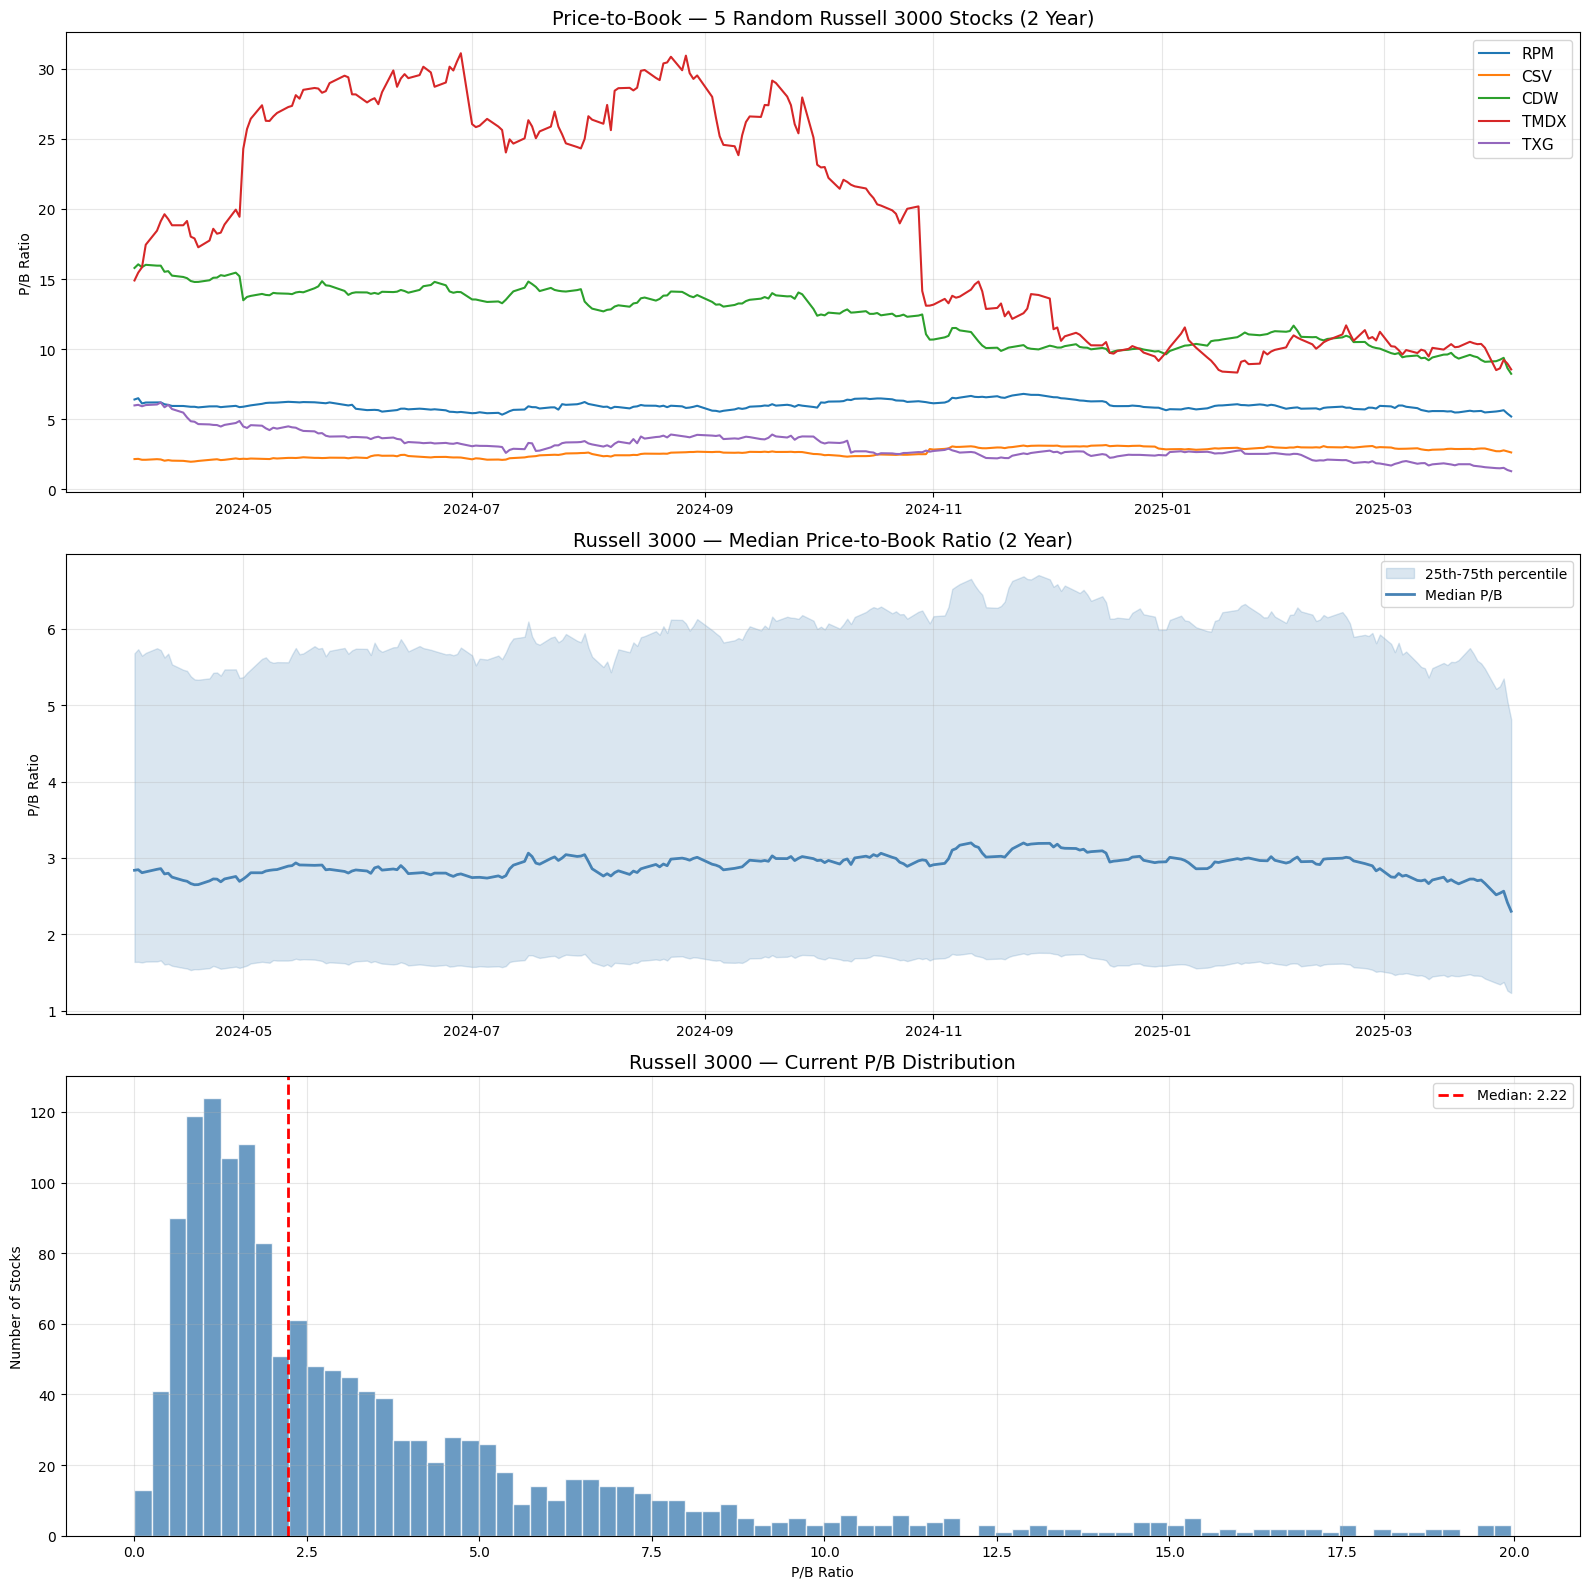


Random tickers shown: ['RPM', 'CSV', 'CDW', 'TMDX', 'TXG']

Summary Stats (current P/B):
count    1508.00
mean        5.62
std        18.33
min         0.00
25%         1.23
50%         2.30
75%         4.81
max       322.92
Name: 2025-04-04 00:00:00, dtype: float64


In [59]:
# --- Plot Price-to-Book Ratios ---

# Pick 5 random tickers that have data
valid_tickers = pb_df.columns[pb_df.notna().sum() > 50].tolist()
sample_tickers = random.sample(valid_tickers, min(5, len(valid_tickers)))

fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# Plot 1: 5 random individual tickers
ax1 = axes[0]
for t in sample_tickers:
    ax1.plot(pb_df.index, pb_df[t], linewidth=1.5, label=t)
ax1.set_title("Price-to-Book — 5 Random Russell 3000 Stocks (2 Year)", fontsize=14)
ax1.set_ylabel("P/B Ratio")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Median P/B with interquartile range
ax2 = axes[1]
median_pb = pb_df.median(axis=1)
q25_pb = pb_df.quantile(0.25, axis=1)
q75_pb = pb_df.quantile(0.75, axis=1)
ax2.fill_between(median_pb.index, q25_pb, q75_pb, alpha=0.2, color="steelblue", label="25th-75th percentile")
ax2.plot(median_pb.index, median_pb, color="steelblue", linewidth=2, label="Median P/B")
ax2.set_title("Russell 3000 — Median Price-to-Book Ratio (2 Year)", fontsize=14)
ax2.set_ylabel("P/B Ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of current P/B values
ax3 = axes[2]
current_pb = pb_df.iloc[-1].dropna()
current_pb_clipped = current_pb[(current_pb > 0) & (current_pb < 20)]
ax3.hist(current_pb_clipped, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax3.axvline(current_pb_clipped.median(), color="red", linestyle="--", linewidth=2, label=f"Median: {current_pb_clipped.median():.2f}")
ax3.set_title("Russell 3000 — Current P/B Distribution", fontsize=14)
ax3.set_xlabel("P/B Ratio")
ax3.set_ylabel("Number of Stocks")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nRandom tickers shown: {sample_tickers}")
print(f"\nSummary Stats (current P/B):")
print(current_pb.describe().round(2))

In [60]:
# --- Data Quality Check ---

# Coverage per ticker: % of trading days with non-null P/B
coverage = pb_df.notna().sum() / pb_df.shape[0] * 100

# Buckets
good = coverage[coverage >= 90]
partial = coverage[(coverage >= 50) & (coverage < 90)]
sparse = coverage[(coverage > 0) & (coverage < 50)]
zero = coverage[coverage == 0]

print(f"=== P/B Data Coverage ({pb_df.shape[0]} trading days) ===")
print(f"  Good (>=90%):    {len(good)} tickers")
print(f"  Partial (50-90%): {len(partial)} tickers")
print(f"  Sparse (<50%):   {len(sparse)} tickers")
print(f"  No data (0%):    {len(zero)} tickers")

# What's causing NaNs — is it Market Cap or Equity?
mktcap_coverage = mktcap.notna().sum() / mktcap.shape[0] * 100
equity_coverage = equity_daily.notna().sum() / equity_daily.shape[0] * 100

mktcap_missing = (mktcap_coverage == 0).sum()
equity_missing = (equity_coverage == 0).sum()

print(f"\n=== Root Cause ===")
print(f"  Tickers with NO Market Cap data:  {mktcap_missing}")
print(f"  Tickers with NO Equity data:      {equity_missing}")

# Show tickers with zero data
print(f"\n=== Tickers with 0% P/B coverage ===")
print(zero.index.tolist())

# Show sparse tickers
if len(sparse) > 0:
    print(f"\n=== Sparse tickers (<50% coverage) ===")
    for t in sparse.sort_values().index[:20]:
        mc_pct = mktcap_coverage.get(t, 0)
        eq_pct = equity_coverage.get(t, 0)
        print(f"  {t:6s}: P/B={coverage[t]:.0f}% | MktCap={mc_pct:.0f}% | Equity={eq_pct:.0f}%")

=== P/B Data Coverage (254 trading days) ===
  Good (>=90%):    1298 tickers
  Partial (50-90%): 17 tickers
  Sparse (<50%):   194 tickers
  No data (0%):    718 tickers

=== Root Cause ===
  Tickers with NO Market Cap data:  51
  Tickers with NO Equity data:      101

=== Tickers with 0% P/B coverage ===
['AAL', 'AAP', 'ABCB', 'ABM', 'ACGL', 'ACI', 'ACIC', 'ACM', 'ACNB', 'ACT', 'ADCT', 'ADEA', 'ADNT', 'ADTN', 'AEO', 'AES', 'AFG', 'AFL', 'AGNC', 'AGO', 'AHR', 'AIG', 'AIP', 'AIR', 'AIZ', 'ALK', 'ALL', 'ALLY', 'ALNT', 'ALRS', 'AMAL', 'AMBP', 'AMRX', 'AMSF', 'AMT', 'AMTB', 'APD', 'APGE', 'APPN', 'AQST', 'ARES', 'ARI', 'AROW', 'ARRY', 'ARVN', 'AS', 'ASB', 'ASH', 'ATEC', 'ATNI', 'AUB', 'AVAH', 'AVNW', 'AWK', 'AWR', 'AX', 'AXON', 'AXP', 'AXS', 'AZO', 'BA', 'BAC', 'BAM', 'BANC', 'BANF', 'BANR', 'BATRA', 'BATRK', 'BBAI', 'BBBY', 'BBIO', 'BBNX', 'BBUC', 'BBW', 'BBWI', 'BCBP', 'BCC', 'BCML', 'BCRX', 'BEN', 'BEPC', 'BFC', 'BFH', 'BFST', 'BHB', 'BHF', 'BILL', 'BIPC', 'BJ', 'BK', 'BKNG', 'BKU', 'BL

In [63]:
# --- Fetch equity data from SEC EDGAR for ALL tickers ---
import os
cache_file = "edgar_equity_cache.json"

# Load ticker -> CIK mapping
resp = requests.get("https://www.sec.gov/files/company_tickers.json", headers=SEC_HEADERS)
ticker_map = resp.json()
cik_lookup = {v["ticker"]: str(v["cik_str"]).zfill(10) for v in ticker_map.values()}

# Load existing cache
if os.path.exists(cache_file):
    with open(cache_file, "r") as f:
        edgar_cache = json.load(f)
    print(f"Loaded cache with {len(edgar_cache)} tickers")
else:
    edgar_cache = {}

# Fetch for ALL matched tickers, not just backfill
all_fetch = Tickers_matched
remaining = [t for t in all_fetch if t not in edgar_cache]
no_cik = [t for t in remaining if t not in cik_lookup]
remaining = [t for t in remaining if t in cik_lookup]

print(f"Total tickers: {len(all_fetch)}")
print(f"Already cached:   {len(edgar_cache)}")
print(f"No CIK found:     {len(no_cik)}")
print(f"To fetch:          {len(remaining)}")

batch_size = 50
failed = []
for i in range(0, len(remaining), batch_size):
    batch = remaining[i:i+batch_size]
    print(f"  Batch {i//batch_size + 1}/{(len(remaining)-1)//batch_size + 1}: {len(batch)} tickers...", end=" ")
    
    got = 0
    for t in batch:
        cik = cik_lookup[t]
        url = f"https://data.sec.gov/api/xbrl/companyconcept/CIK{cik}/us-gaap/StockholdersEquity.json"
        try:
            resp = requests.get(url, headers=SEC_HEADERS)
            if resp.status_code == 200:
                data = resp.json()
                entries = data.get("units", {}).get("USD", [])
                by_date = {}
                for e in entries:
                    if e["form"] in ("10-Q", "10-K") and "frame" in e:
                        by_date[e["end"]] = e["val"]
                edgar_cache[t] = by_date
                if by_date:
                    got += 1
            else:
                edgar_cache[t] = {}
        except Exception as ex:
            edgar_cache[t] = {}
            failed.append((t, str(ex)))
        
        time.sleep(0.125)
    
    with open(cache_file, "w") as f:
        json.dump(edgar_cache, f)
    print(f"got data for {got}/{len(batch)}")

has_data = sum(1 for t in all_fetch if edgar_cache.get(t))
print(f"\n=== EDGAR Summary ===")
print(f"Tickers with equity data: {has_data} / {len(all_fetch)}")
print(f"No CIK mapping: {len(no_cik)}")
if no_cik:
    print(f"  Sample: {no_cik[:10]}")
if failed:
    print(f"Errors: {len(failed)}, sample: {failed[:5]}")

In [ ]:
# --- Fetch All Financial Data from SEC EDGAR ---
from edgar_utils import load_cik_lookup, fetch_concept, cache_to_unstacked, build_daily_instant, build_daily_ttm

cik_lookup = load_cik_lookup()

# Instant concepts (balance sheet)
edgar_equity = fetch_concept(Tickers_matched, "StockholdersEquity", "edgar_equity_cache.json", cik_lookup, "instant")
edgar_debt = fetch_concept(Tickers_matched, "LongTermDebt", "edgar_debt_cache.json", cik_lookup, "instant")
edgar_cash = fetch_concept(Tickers_matched, "CashAndCashEquivalentsAtCarryingValue", "edgar_cash_cache.json", cik_lookup, "instant")

# Duration concepts (income statement) — these are quarterly values
edgar_revenue = fetch_concept(Tickers_matched, "Revenues", "edgar_revenue_cache.json", cik_lookup, "duration")
edgar_net_income = fetch_concept(Tickers_matched, "NetIncomeLoss", "edgar_netincome_cache.json", cik_lookup, "duration")
edgar_op_income = fetch_concept(Tickers_matched, "OperatingIncomeLoss", "edgar_opincome_cache.json", cik_lookup, "duration")
edgar_dna = fetch_concept(Tickers_matched, "DepreciationDepletionAndAmortization", "edgar_dna_cache.json", cik_lookup, "duration")

print("All EDGAR concepts fetched.")

In [ ]:
# --- Compute Valuation Ratios ---
trading_dates = mktcap.index

# === Price-to-Book ===
eq_unstacked = cache_to_unstacked(edgar_equity)
equity_daily = build_daily_instant(eq_unstacked, trading_dates)

# Handle negative equity: mask everything at/before last negative date
neg_mask = equity_daily <= 0
last_neg = neg_mask.apply(lambda col: col[col].index.max() if col.any() else pd.NaT)
for t in equity_daily.columns:
    if pd.notna(last_neg[t]):
        equity_daily.loc[:last_neg[t], t] = np.nan

pb_df = (mktcap / equity_daily).replace([np.inf, -np.inf], np.nan)

# === Price-to-Sales (TTM) ===
rev_unstacked = cache_to_unstacked(edgar_revenue)
revenue_ttm = build_daily_ttm(rev_unstacked, trading_dates)
ps_df = (mktcap / revenue_ttm).replace([np.inf, -np.inf], np.nan)

# === Price-to-Earnings (TTM) ===
ni_unstacked = cache_to_unstacked(edgar_net_income)
net_income_ttm = build_daily_ttm(ni_unstacked, trading_dates)
# Only compute P/E for positive earnings
net_income_ttm_pos = net_income_ttm.where(net_income_ttm > 0)
pe_df = (mktcap / net_income_ttm_pos).replace([np.inf, -np.inf], np.nan)

# === EV/EBITDA (TTM) ===
# Enterprise Value = Market Cap + Total Debt - Cash
debt_unstacked = cache_to_unstacked(edgar_debt)
cash_unstacked = cache_to_unstacked(edgar_cash)
debt_daily = build_daily_instant(debt_unstacked, trading_dates)
cash_daily = build_daily_instant(cash_unstacked, trading_dates)

# Align columns before arithmetic
common_ev = mktcap.columns.intersection(debt_daily.columns).intersection(cash_daily.columns)
ev_df = mktcap[common_ev] + debt_daily[common_ev].fillna(0) - cash_daily[common_ev].fillna(0)

# EBITDA = Operating Income + D&A
oi_unstacked = cache_to_unstacked(edgar_op_income)
dna_unstacked = cache_to_unstacked(edgar_dna)
# Align before adding
common_ebitda = oi_unstacked.columns.intersection(dna_unstacked.columns)
ebitda_quarterly = oi_unstacked[common_ebitda] + dna_unstacked[common_ebitda].fillna(0)
ebitda_ttm = build_daily_ttm(ebitda_quarterly, trading_dates)

# Only compute for positive EBITDA
ebitda_ttm_pos = ebitda_ttm.where(ebitda_ttm > 0)
common_all = ev_df.columns.intersection(ebitda_ttm_pos.columns)
ev_ebitda_df = (ev_df[common_all] / ebitda_ttm_pos[common_all]).replace([np.inf, -np.inf], np.nan)

# === Summary ===
for name, df in [("P/B", pb_df), ("P/S", ps_df), ("P/E", pe_df), ("EV/EBITDA", ev_ebitda_df)]:
    cov = df.notna().sum() / df.shape[0] * 100
    good = (cov >= 90).sum()
    print(f"{name:12s}: {df.shape[1]} tickers | {df.count().sum():>8,} non-null | {good} good (>=90%)")

In [ ]:
# --- Plot All Valuation Ratios ---
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

for ax, (name, df, ylim) in zip(axes, [
    ("Price-to-Book", pb_df, (0, 8)),
    ("Price-to-Sales (TTM)", ps_df, (0, 15)),
    ("Price-to-Earnings (TTM)", pe_df, (0, 60)),
    ("EV/EBITDA (TTM)", ev_ebitda_df, (0, 40)),
]):
    median = df.median(axis=1)
    q25 = df.quantile(0.25, axis=1)
    q75 = df.quantile(0.75, axis=1)
    ax.fill_between(median.index, q25, q75, alpha=0.2, color="steelblue", label="25th-75th pctl")
    ax.plot(median.index, median, color="steelblue", linewidth=2, label="Median")
    ax.set_title(f"Russell 3000 — {name} (2 Year)", fontsize=14)
    ax.set_ylabel(name)
    ax.set_ylim(ylim)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()